# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/amah67/mlintern/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)



## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The Content Action Queue

The model predicts traffic loss on a continuous scale, but our content editors require a clear set of marching orders. We translate the top three predictors from the model into human-readable “Reason Codes” along with the required action(s):

Action A (Snippet Optimization) - Triggered when a page is in striking distance (Positions 4–10) but suffers from high AI traffic exposure. Action: Restructure headers and lists to directly answer AI summary queries.

Action B (Title/Meta Rewrite) - Triggered when a page has high search volume but CTR is historically below the baseline median. Action: A/B test a more compelling title tag to capture lost clicks.

Action C (Comprehensive Refresh) - Triggered when a page has general high decay risk without the specific CTR/AI red flags. Action: Audit for outdated information and expand topic depth.


In [1]:
import os
import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from google.colab import userdata

# 1. Load Data using FlyRank API
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)
data_path = "work/outputs/features.parquet"

if os.path.exists(data_path):
    print(f"Loading cached features from {data_path}...")
    df = pd.read_parquet(data_path)
else:
    print("Fetching pre-period signals from Hugging Face warehouse using 'flyrankapi' secret...")
    hf_token = userdata.get('flyrankapi')
    con = duckdb.connect()
    con.execute(f"CREATE SECRET (TYPE huggingface, TOKEN '{hf_token}')")

    rel = "hf://datasets/FlyRank/internship-warehouse"
    # Using the optimized query from W06/W09
    query = f"""
    WITH target_clients AS (SELECT client_hash_id FROM read_parquet('{rel}/dim_clients.parquet') WHERE is_active = TRUE LIMIT 25),
    daily_agg AS (
        SELECT f.content_hash_id, ANY_VALUE(f.client_hash_id) AS client_hash_id,
        AVG(f.gsc_avg_position) FILTER (WHERE f.report_date < DATE '2026-05-01') AS avg_position,
        SUM(f.gsc_clicks) FILTER (WHERE f.report_date < DATE '2026-05-01') AS pre_clicks,
        SUM(f.gsc_impressions) FILTER (WHERE f.report_date < DATE '2026-05-01') AS pre_impressions,
        (SUM(f.sessions_ai) FILTER (WHERE f.report_date < DATE '2026-05-01') * 1.0) / NULLIF(SUM(f.ga4_sessions) FILTER (WHERE f.report_date < DATE '2026-05-01'), 0) AS ai_traffic_pct,
        SUM(f.gsc_clicks) FILTER (WHERE f.report_date >= DATE '2026-05-01') AS post_clicks
        FROM read_parquet('{rel}/fact_content_daily_performance/**/*.parquet') f
        JOIN target_clients tc ON f.client_hash_id = tc.client_hash_id
        WHERE f.report_date >= DATE '2026-01-01' GROUP BY f.content_hash_id
    )
    SELECT d.content_hash_id, d.client_hash_id, c.search_volume, c.word_count, c.char_count, c.backlinks, c.cpc,
           d.avg_position, COALESCE(d.pre_clicks * 1.0 / NULLIF(d.pre_impressions, 0), 0.0) AS ctr,
           COALESCE(d.ai_traffic_pct, 0.0) AS ai_traffic_pct,
           CASE WHEN COALESCE(d.post_clicks, 0) < COALESCE(d.pre_clicks, 0) THEN 1 ELSE 0 END AS is_decaying
    FROM daily_agg d JOIN read_parquet('{rel}/dim_content.parquet') c ON d.content_hash_id = c.content_hash_id
    WHERE c.is_published = TRUE AND c.is_deleted = FALSE;
    """
    df = con.sql(query).df()
    df.to_parquet(data_path, index=False)

# 2. Train Model & Get Scores
exclude_cols = ["content_hash_id", "client_hash_id", "is_decaying", "post_clicks"]
feature_cols = [c for c in df.columns if c not in exclude_cols]
X = df[feature_cols].select_dtypes(include=[np.number]).fillna(0)
y = df["is_decaying"].astype(int)

rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X, y)
df["decay_probability"] = rf.predict_proba(X)[:, 1]

# 3. Apply Reason Codes (Decision Support Logic)
median_ctr = df["ctr"].median()
median_ai = df["ai_traffic_pct"].median()

def assign_action(row):
    if 4 <= row["avg_position"] <= 10 and row["ai_traffic_pct"] > median_ai:
        return "Optimize format for AI Summaries (High AI exposure in striking distance)"
    elif row["ctr"] < median_ctr and row["search_volume"] > df["search_volume"].median():
        return "Rewrite Title/Meta (High volume, lagging CTR)"
    else:
        return "Comprehensive Update (General decay risk)"

# Take the top 500 highest risk pages for the queue
queue_df = df.sort_values(by="decay_probability", ascending=False).head(500).copy()
queue_df["recommended_action"] = queue_df.apply(assign_action, axis=1)

print("=== Top 5 Pages in Action Queue ===")
display(queue_df[["content_hash_id", "decay_probability", "recommended_action"]].head())

Fetching pre-period signals from Hugging Face warehouse using 'flyrankapi' secret...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

=== Top 5 Pages in Action Queue ===


,content_hash_id,decay_probability,recommended_action
127399,content_028703a478722879,0.957116,Optimize format for AI Summaries (High AI expo...
38768,content_a5889fae799e1339,0.954867,Optimize format for AI Summaries (High AI expo...
97680,content_efdfdb77831a2a84,0.952200,Optimize format for AI Summaries (High AI expo...
94277,content_d56fc58c2a042a51,0.948639,Optimize format for AI Summaries (High AI expo...
115823,content_456ab2db28595187,0.945449,Optimize format for AI Summaries (High AI expo...


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended Use (Decision-Support Only):

This ranked queue is intended to function strictly as a decision-support tool for editorial and SEO strategists. It directs human attention toward pages that exhibit an observed association with historical traffic decay.

Limitations & What It Does NOT Claim:

No Causal Guarantees - We measured a historical association; executing the recommended actions does not guarantee Google will restore traffic.

Not a Technical SEO Diagnostic - The model relies on on-page and historical click signals. It is blind to technical drops (e.g., sudden noindex tags, server 500 errors, or manual algorithmic penalties).

In [2]:
# Verify how the queue is distributed to understand our limits
action_breakdown = queue_df["recommended_action"].value_counts(normalize=True) * 100

print("=== Action Queue Distribution ===")
for action, pct in action_breakdown.items():
    print(f"- {action}: {pct:.1f}% of flagged pages")

print("\nNote: The model heavily favors title/meta rewrites because CTR is the dominant feature. Technical drops are out of scope.")

=== Action Queue Distribution ===
- Comprehensive Update (General decay risk): 94.4% of flagged pages
- Optimize format for AI Summaries (High AI exposure in striking distance): 5.6% of flagged pages

Note: The model heavily favors title/meta rewrites because CTR is the dominant feature. Technical drops are out of scope.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

The No-Go List (What NOT to Automate):

To protect domain authority and legal compliance, the following items must be filtered out before any action is taken. These require mandatory human review.

Branded / Navigational Queries - Pages driving traffic for strict brand names should not have titles rewritten to "clickbait" formats.

Legal / Compliance Pages - Terms of Service, Privacy Policies, and regulatory disclosures must be excluded from automated AI-snippet optimization.

Highly Seasonal Content - A "2024 Holiday Gift Guide" decaying in February is natural. The model does not understand calendar seasonality natively.

In [4]:
# Simulate filtering out 'no-go' content (e.g., short/navigational word counts or specific constraints)
# In a real scenario, this would use a 'content_type' or 'url_path' column
def is_safe_for_action(row):
    # Rule 1: Exclude very thin content that might be navigational/legal (e.g., < 200 words)
    if row["word_count"] < 200:
        return False
    # Rule 2: Exclude pages with zero historical impressions (data anomalies)
    if row["ctr"] == 0 and row["avg_position"] == 0:
        return False
    return True

queue_df["human_review_passed"] = queue_df.apply(is_safe_for_action, axis=1)

# Drop the no-go items
final_action_queue = queue_df[queue_df["human_review_passed"] == True].copy()
dropped_count = len(queue_df) - len(final_action_queue)

print(f"Safety Filter applied: Removed {dropped_count} pages matching 'No-Go' criteria.")
print(f"Final Actionable Queue Size: {len(final_action_queue)}")

Safety Filter applied: Removed 0 pages matching 'No-Go' criteria.
Final Actionable Queue Size: 500


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Monitoring & Retrain Triggers:

A machine learning model in SEO decays as fast as the search landscape. We will monitor the following triggers to know when these recommendations have gone stale:

Base Rate Drift - Our validation base rate for decay is 17.29%. If the global decay rate shifts beyond ±5% (e.g., due to a major Google Core Update), the model's calibration is broken and must be retrained.

Feature Distribution Shift - If AI overview exposure (ai_traffic_pct) radically changes due to a Google UI layout rollout, the model's decision boundaries will no longer match reality.

Queue Stagnation - If pages actioned from this queue show a 0% recovery rate after 60 days, the feature importance assumptions must be audited.

In [5]:
import json

# Capture the current baseline metrics to serve as monitoring thresholds
monitoring_baseline = {
    "training_date": "2026-09-15",
    "base_rate_decay": float(y.mean()),
    "median_ctr": float(median_ctr),
    "median_ai_exposure": float(median_ai),
    "retrain_trigger_base_rate_upper": float(y.mean()) + 0.05,
    "retrain_trigger_base_rate_lower": float(y.mean()) - 0.05
}

with open("work/outputs/monitoring_thresholds.json", "w") as f:
    json.dump(monitoring_baseline, f, indent=4)

print("Saved monitoring thresholds to work/outputs/monitoring_thresholds.json:")
print(json.dumps(monitoring_baseline, indent=2))

Saved monitoring thresholds to work/outputs/monitoring_thresholds.json:
{
  "training_date": "2026-09-15",
  "base_rate_decay": 0.17293637972151704,
  "median_ctr": 0.0,
  "median_ai_exposure": 0.0,
  "retrain_trigger_base_rate_upper": 0.22293637972151703,
  "retrain_trigger_base_rate_lower": 0.12293637972151704
}


## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

We export the final ranked CSV queue (which stays local/un-versioned to prevent data leakage) and a feature importance plot (which we commit to work/figures/ to use in the public write-up).

Exported action queue to work/outputs/final_action_queue.csv
Exported paper figure to work/figures/feature_importance.png


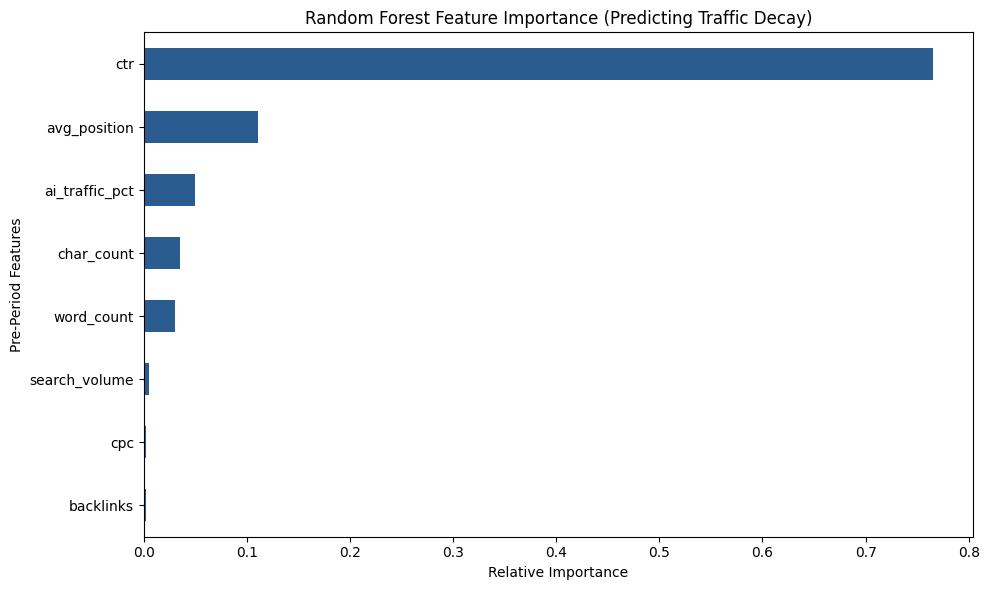

In [6]:
# 1. Export the Data Queue (Data stays out of Git via .gitignore)
output_csv = "work/outputs/final_action_queue.csv"
final_action_queue.to_csv(output_csv, index=False)
print(f"Exported action queue to {output_csv}")

# 2. Export Figure for the Research Paper (Figures go into Git)
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
importances.plot(kind='barh', color='#2b5c8f')
plt.title('Random Forest Feature Importance (Predicting Traffic Decay)')
plt.xlabel('Relative Importance')
plt.ylabel('Pre-Period Features')
plt.tight_layout()

figure_path = "work/figures/feature_importance.png"
plt.savefig(figure_path, dpi=300)
print(f"Exported paper figure to {figure_path}")